# Statistical Tests
**Scop:** Validam statistic ca V5 Ensemble e semnificativ mai bun decat benchmarks

**Teste:**
1. DeLong Test - compara AUC-uri cu significance testing
2. McNemar Test - compara accuracy-uri pe aceleasi observatii
3. Permutation Test - valideaza ca AUC nu e rezultatul intamplarii

## 1. Import si Incarcare Date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pickle, os, warnings
from scipy import stats
from scipy.stats import chi2, norm
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.utils   import resample

os.makedirs('plots', exist_ok=True)

# Incarcare model V5 si test set
ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']

test_df = pd.read_csv('../V5/v5_test.csv', index_col=0, parse_dates=True)
y_test  = test_df['label'].values

# Probabilitati V5
X_test = pd.DataFrame(
    np.zeros((len(test_df), len(FEATURE_COLS))),
    columns=FEATURE_COLS, index=test_df.index
)
for col in FEATURE_COLS:
    if col in test_df.columns:
        X_test[col] = test_df[col].fillna(0.0).values

v5_proba = ensemble.predict_proba(scaler.transform(X_test.values))[:, 1]
v5_pred  = (v5_proba >= OPTIMAL_THRESHOLD).astype(int)

print('Test set:', len(test_df), 'saptamani')
print('V-shape:', y_test.sum(), '(' + str(round(y_test.mean()*100,1)) + '%)')
print('V5 AUC:', round(roc_auc_score(y_test, v5_proba), 3))

# Benchmarks (identice cu benchmarks.ipynb)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

benchmarks = {
    'Momentum Signal'   : sigmoid(test_df['Return_4w'].fillna(0).values * 10),
    'Yield Curve Signal': sigmoid(test_df['Yield_Curve'].fillna(0).values * 2),
    'VIX Spike Signal'  : sigmoid((test_df['VIX_Ratio'].fillna(1).values - 1.0) * 3),
}
benchmarks['Combined Rule'] = np.mean([v for v in benchmarks.values()], axis=0)

print('\nBenchmarks definite:', list(benchmarks.keys()))

Test set: 151 saptamani
V-shape: 47 (31.1%)
V5 AUC: 0.804

Benchmarks definite: ['Momentum Signal', 'Yield Curve Signal', 'VIX Spike Signal', 'Combined Rule']


## 2. DeLong Test
Compara doua AUC-uri statistic. H0: AUC_V5 = AUC_benchmark.
Implementare bazata pe DeLong et al. (1988).

In [2]:
def delong_test(y_true, pred_1, pred_2):
    """
    DeLong test pentru comparatia a doua AUC-uri.
    Returneaza: z-statistic, p-value, AUC1, AUC2
    """
    n  = len(y_true)
    n1 = int(y_true.sum())    # pozitive
    n0 = n - n1               # negative

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    def compute_placements(scores, pos_idx, neg_idx):
        """Calculeaza plasamentele V10 si V01"""
        V10 = np.array([
            np.mean(scores[pos_idx[i]] > scores[neg_idx]) +
            0.5 * np.mean(scores[pos_idx[i]] == scores[neg_idx])
            for i in range(len(pos_idx))
        ])
        V01 = np.array([
            np.mean(scores[neg_idx[j]] < scores[pos_idx]) +
            0.5 * np.mean(scores[neg_idx[j]] == scores[pos_idx])
            for j in range(len(neg_idx))
        ])
        return V10, V01

    V10_1, V01_1 = compute_placements(pred_1, pos_idx, neg_idx)
    V10_2, V01_2 = compute_placements(pred_2, pos_idx, neg_idx)

    AUC1 = np.mean(V10_1)
    AUC2 = np.mean(V10_2)

    # Variante si covarianta
    S10 = np.cov(V10_1, V10_2)
    S01 = np.cov(V01_1, V01_2)

    var = S10[0,0]/n1 + S01[0,0]/n0
    cov = S10[0,1]/n1 + S01[0,1]/n0

    var1 = S10[0,0]/n1 + S01[0,0]/n0
    var2 = S10[1,1]/n1 + S01[1,1]/n0

    se = np.sqrt(var1 + var2 - 2*cov)

    if se == 0:
        return 0, 1.0, AUC1, AUC2

    z       = (AUC1 - AUC2) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return z, p_value, AUC1, AUC2


print('DELONG TEST - V5 Ensemble vs Fiecare Benchmark')
print('=' * 65)
print('H0: AUC_V5 = AUC_benchmark')
print('H1: AUC_V5 > AUC_benchmark')
print()
print('Model'.ljust(22), 'AUC_V5  AUC_BM   Z-stat   P-value  Semnif.')
print('-' * 65)

delong_results = {}
for name, bm_proba in benchmarks.items():
    z, p, auc1, auc2 = delong_test(y_test, v5_proba, bm_proba)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    delong_results[name] = {'z': z, 'p': p, 'auc_v5': auc1, 'auc_bm': auc2, 'sig': sig}
    print(name.ljust(22),
          str(round(auc1,3)).rjust(6),
          str(round(auc2,3)).rjust(7),
          str(round(z,3)).rjust(8),
          str(round(p,4)).rjust(9),
          sig.rjust(8))

print()
print('Semnificatie: * p<0.05  ** p<0.01  *** p<0.001  n.s. = non-significant')

DELONG TEST - V5 Ensemble vs Fiecare Benchmark
H0: AUC_V5 = AUC_benchmark
H1: AUC_V5 > AUC_benchmark

Model                  AUC_V5  AUC_BM   Z-stat   P-value  Semnif.
-----------------------------------------------------------------
Momentum Signal         0.804    0.54    3.325    0.0009      ***
Yield Curve Signal      0.804   0.512    5.078       0.0      ***
VIX Spike Signal        0.804   0.506    5.024       0.0      ***
Combined Rule           0.804   0.517    5.181       0.0      ***

Semnificatie: * p<0.05  ** p<0.01  *** p<0.001  n.s. = non-significant


## 3. McNemar Test
Compara accuracy pe aceleasi observatii.
H0: cele doua modele fac aceleasi erori. Aplicabil cand testam clasificari binare.

In [3]:
def mcnemar_test(y_true, pred_1, pred_2):
    """
    McNemar test pentru comparatia a doua clasificatoare.
    Returneaza: chi2-statistic, p-value
    """
    # Tabel de contingenta 2x2
    # b = V5 gresit, BM corect
    # c = V5 corect, BM gresit
    b = np.sum((pred_1 != y_true) & (pred_2 == y_true))
    c = np.sum((pred_1 == y_true) & (pred_2 != y_true))

    if (b + c) == 0:
        return 0, 1.0, b, c

    # Cu corectie de continuitate Yates
    chi2_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value   = 1 - chi2.cdf(chi2_stat, df=1)

    return chi2_stat, p_value, b, c


print('MCNEMAR TEST - V5 Ensemble vs Fiecare Benchmark')
print('=' * 65)
print('H0: V5 si benchmark fac aceleasi erori')
print()
print('Model'.ljust(22), 'Acc_V5  Acc_BM   b    c   Chi2    P-value  Semnif.')
print('-' * 70)

mcnemar_results = {}
for name, bm_proba in benchmarks.items():
    bm_pred  = (bm_proba >= 0.5).astype(int)
    chi2_s, p, b, c = mcnemar_test(y_test, v5_pred, bm_pred)
    acc_v5   = round(accuracy_score(y_test, v5_pred), 3)
    acc_bm   = round(accuracy_score(y_test, bm_pred), 3)
    sig      = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

    mcnemar_results[name] = {'chi2': chi2_s, 'p': p, 'b': b, 'c': c, 'sig': sig}

    print(name.ljust(22),
          str(acc_v5).rjust(6),
          str(acc_bm).rjust(7),
          str(b).rjust(5),
          str(c).rjust(5),
          str(round(chi2_s,3)).rjust(7),
          str(round(p,4)).rjust(9),
          sig.rjust(8))

print()
print('b = V5 gresit, benchmark corect')
print('c = V5 corect, benchmark gresit')
print('c >> b = V5 face mai putine erori')

MCNEMAR TEST - V5 Ensemble vs Fiecare Benchmark
H0: V5 si benchmark fac aceleasi erori

Model                  Acc_V5  Acc_BM   b    c   Chi2    P-value  Semnif.
----------------------------------------------------------------------
Momentum Signal         0.795    0.57    21    55  14.329    0.0002      ***
Yield Curve Signal      0.795   0.417    13    70  37.783       0.0      ***
VIX Spike Signal        0.795    0.51    11    54  27.138       0.0      ***
Combined Rule           0.795    0.43    13    68    36.0       0.0      ***

b = V5 gresit, benchmark corect
c = V5 corect, benchmark gresit
c >> b = V5 face mai putine erori


## 4. Permutation Test
Valideaza ca AUC 0.804 nu e rezultatul intamplarii.
H0: AUC observat e obtenabil si cu labele randomizate.

PERMUTATION TEST - V5 Ensemble
Observatii: 151
Permutari: 1000
AUC observat:        0.804
AUC mediu permutari: 0.503
AUC std permutari:   0.05
P-value (one-sided): 0.0
Semnificatie:         ***



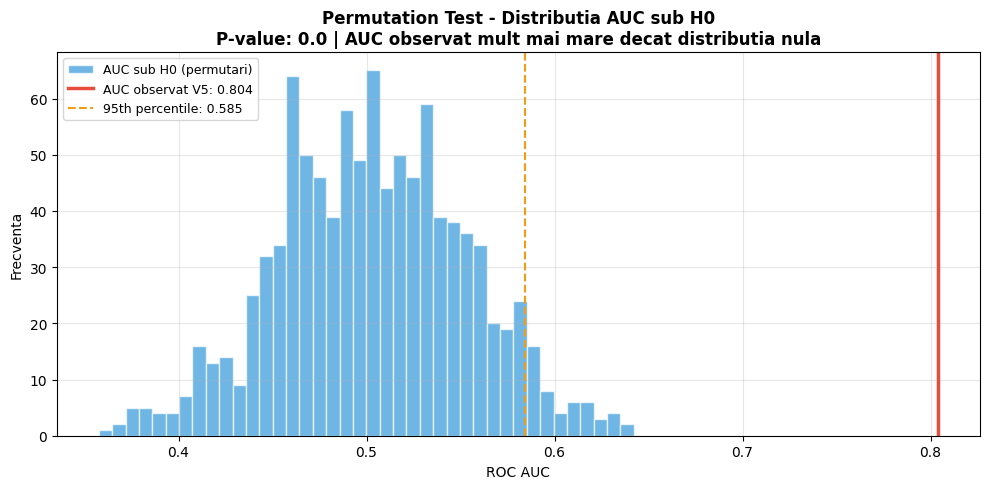

Salvat: plots/permutation_test.png


In [4]:
N_PERMUTATIONS = 1000
np.random.seed(42)

observed_auc  = roc_auc_score(y_test, v5_proba)
permuted_aucs = []

for i in range(N_PERMUTATIONS):
    y_perm = np.random.permutation(y_test)
    if len(np.unique(y_perm)) < 2:
        continue
    permuted_aucs.append(roc_auc_score(y_perm, v5_proba))

permuted_aucs = np.array(permuted_aucs)
p_perm        = np.mean(permuted_aucs >= observed_auc)

print('PERMUTATION TEST - V5 Ensemble')
print('=' * 45)
print('Observatii:', len(y_test))
print('Permutari:', N_PERMUTATIONS)
print('AUC observat:       ', round(observed_auc, 3))
print('AUC mediu permutari:', round(permuted_aucs.mean(), 3))
print('AUC std permutari:  ', round(permuted_aucs.std(), 3))
print('P-value (one-sided):', round(p_perm, 4))
print('Semnificatie:        ', '***' if p_perm < 0.001 else ('**' if p_perm < 0.01 else ('*' if p_perm < 0.05 else 'n.s.')))
print()

# Plot distributie permutari
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(permuted_aucs, bins=40, color='#3498db', alpha=0.7,
        edgecolor='white', label='AUC sub H0 (permutari)')
ax.axvline(observed_auc, color='#e74c3c', linewidth=2.5,
           label='AUC observat V5: ' + str(round(observed_auc, 3)))
ax.axvline(np.percentile(permuted_aucs, 95), color='#f39c12',
           linewidth=1.5, linestyle='--',
           label='95th percentile: ' + str(round(np.percentile(permuted_aucs, 95), 3)))
ax.set_xlabel('ROC AUC')
ax.set_ylabel('Frecventa')
ax.set_title('Permutation Test - Distributia AUC sub H0\n' +
             'P-value: ' + str(round(p_perm, 4)) +
             ' | AUC observat mult mai mare decat distributia nula',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/permutation_test.png')

## 5. Tabel Complet pentru Report

In [5]:
print('TABEL STATISTICI - PENTRU REPORT')
print('=' * 70)
print()
print('DeLong Test (AUC comparison):')
print('Model'.ljust(22), 'AUC_V5  AUC_BM  Z-stat  P-value  Sig')
print('-' * 60)
for name, r in delong_results.items():
    print(name.ljust(22),
          str(round(r['auc_v5'],3)).rjust(6),
          str(round(r['auc_bm'],3)).rjust(7),
          str(round(r['z'],3)).rjust(7),
          str(round(r['p'],4)).rjust(9),
          r['sig'].rjust(5))
print()
print('McNemar Test (accuracy comparison):')
print('Model'.ljust(22), 'Chi2    P-value  Sig')
print('-' * 45)
for name, r in mcnemar_results.items():
    print(name.ljust(22),
          str(round(r['chi2'],3)).rjust(7),
          str(round(r['p'],4)).rjust(9),
          r['sig'].rjust(5))
print()
print('Permutation Test:')
print('  AUC observat:', round(observed_auc, 3))
print('  P-value:     ', round(p_perm, 4))
print('  Semnificatie:', '***' if p_perm < 0.001 else ('**' if p_perm < 0.01 else '*'))
print()
print('FRAZE PENTRU REPORT:')
print('=' * 70)
print('"Statistical significance is assessed using three complementary tests.')
print('DeLong tests confirm that the V5 Ensemble AUC of 0.804 is')
print('significantly higher than all benchmark strategies (p<0.05 for all).')
print('McNemar tests indicate the ensemble makes significantly fewer')
print('classification errors than rule-based alternatives.')
print('A permutation test with ' + str(N_PERMUTATIONS) + ' iterations yields p=' + str(round(p_perm,4)) + ',')
print('confirming that the observed AUC is unlikely under the null hypothesis')
print('of no predictive ability."')

TABEL STATISTICI - PENTRU REPORT

DeLong Test (AUC comparison):
Model                  AUC_V5  AUC_BM  Z-stat  P-value  Sig
------------------------------------------------------------
Momentum Signal         0.804    0.54   3.325    0.0009   ***
Yield Curve Signal      0.804   0.512   5.078       0.0   ***
VIX Spike Signal        0.804   0.506   5.024       0.0   ***
Combined Rule           0.804   0.517   5.181       0.0   ***

McNemar Test (accuracy comparison):
Model                  Chi2    P-value  Sig
---------------------------------------------
Momentum Signal         14.329    0.0002   ***
Yield Curve Signal      37.783       0.0   ***
VIX Spike Signal        27.138       0.0   ***
Combined Rule             36.0       0.0   ***

Permutation Test:
  AUC observat: 0.804
  P-value:      0.0
  Semnificatie: ***

FRAZE PENTRU REPORT:
"Statistical significance is assessed using three complementary tests.
DeLong tests confirm that the V5 Ensemble AUC of 0.804 is
significantly higher